In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as geopd
import matplotlib.pyplot as plt
import subprocess

## Config

In [2]:
DIR = "/home/dy23a.fsu/st/datasets/raw"
DIR = os.path.join(DIR, "DC")
TAXI_DIR = Path(DIR) / "taxi"
BIKE_DIR = Path(DIR) / "bike"

FLOW_MODE = "arrival"  # arrival -> dropoff/end ; departure -> pickup/start
assert FLOW_MODE in {"arrival", "departure"}

CLUSTERS_PATH = "./Neighborhood_Clusters.geojson"

OUT_DIR = Path(DIR)

# DC taxi timestamps are rounded to the hour upstream, so the whole dataset is
# built on a 60-min grid (bike is downsampled to match). DC has only two
# mobilities: taxi and bike (no FHV/TNP/scooter), and BOTH are GPS-based, so
# every endpoint is spatially joined to a neighborhood-cluster polygon.
TAXI_DT_FMT = "%m/%d/%Y %H:%M"

# Optional sub-region filter (analogous to NYC borough / Chicago areas). Set to
# a list of cluster NAMEs (e.g. ["Cluster 2", "Cluster 8"]) to keep only those;
# leave as None / "all" to keep every cluster. DC has no natural borough split,
# so this defaults to all 46 clusters.
TARGET_CLUSTERS = None
TARGET_TAG = "subset"

In [3]:
YEAR = 2025
FREQ = "60min"
TIME_START = pd.Timestamp(f"{YEAR}-01-01 00:00:00")
TIME_END = pd.Timestamp(f"{YEAR + 1}-01-01 00:00:00")
STEPS = pd.date_range(TIME_START, TIME_END, freq=FREQ, inclusive="left")
T = len(STEPS)
FREQ_TAG = FREQ
print(f"YEAR={YEAR}, FREQ={FREQ}, T={T} steps, FLOW_MODE={FLOW_MODE}")

YEAR=2025, FREQ=60min, T=8760 steps, FLOW_MODE=arrival


## Shapefile and helpers

Region order follows the shapefile (sorted by `OBJECTID`); all output `(N, T)`
arrays use this same order. Clusters are identified by `NAME` (e.g. `Cluster 2`).

In [4]:
clusters = geopd.read_file(CLUSTERS_PATH).to_crs("EPSG:4326")
clusters = clusters.sort_values("OBJECTID").reset_index(drop=True)
clusters["region_idx"] = np.arange(len(clusters), dtype=np.int32)
clusters_for_join = clusters[["region_idx", "geometry"]]
N = len(clusters)
bounds = clusters.total_bounds
name_to_region = {str(nm): idx for idx, nm in enumerate(clusters["NAME"].tolist())}
print(f"N={N} neighborhood clusters, bbox={bounds}")

N=46 neighborhood clusters, bbox=[-77.11979522  38.79164435 -76.90914996  38.99596804]


In [5]:
def make_step_idx_fn(freq, n_t):
    def fn(ts_series, fmt=None):
        ts = pd.to_datetime(ts_series, format=fmt, errors="coerce")
        step = ts.dt.floor(freq)
        delta = (step - TIME_START) / pd.Timedelta(freq)
        idx_float = delta.to_numpy(dtype=np.float64)
        valid = np.isfinite(idx_float) & (idx_float >= 0) & (idx_float < n_t)
        step_idx = np.zeros(len(idx_float), dtype=np.int64)
        step_idx[valid] = idx_float[valid].astype(np.int64)
        return step_idx, valid
    return fn

step_idx_60 = make_step_idx_fn(FREQ, T)

def map_points_to_regions(lon_arr, lat_arr, join_gdf, bounds_):
    minx, miny, maxx, maxy = bounds_
    region_idx = np.full(len(lon_arr), -1, dtype=np.int32)
    in_bbox = (
        (lon_arr >= minx)
        & (lon_arr <= maxx)
        & (lat_arr >= miny)
        & (lat_arr <= maxy)
    )
    if not np.any(in_bbox):
        return region_idx
    candidate_ids = np.where(in_bbox)[0]
    pts = geopd.GeoDataFrame(
        {"row_id": candidate_ids},
        geometry=geopd.points_from_xy(lon_arr[in_bbox], lat_arr[in_bbox]),
        crs="EPSG:4326",
    )
    joined = geopd.sjoin(pts, join_gdf, how="left", predicate="intersects")
    matched = joined.dropna(subset=["region_idx"]).drop_duplicates(subset=["row_id"], keep="first")
    region_idx[matched["row_id"].to_numpy(dtype=np.int64)] = matched["region_idx"].to_numpy(dtype=np.int32)
    return region_idx

def accumulate_nt(region_idx, step_idx, time_valid, nt_matrix, n_t):
    valid = time_valid & (region_idx >= 0)
    if not np.any(valid):
        return 0
    flat_idx = region_idx[valid].astype(np.int64) * n_t + step_idx[valid].astype(np.int64)
    binc = np.bincount(flat_idx, minlength=N * n_t)
    nt_matrix += binc.reshape(N, n_t)
    return int(valid.sum())

## Taxi (gps -> shapefile)

The DC taxi CSVs carry block-level lat/lon for both endpoints
(`ORIGIN_BLOCK_LATITUDE/LONGITUDE`, `DESTINATION_BLOCK_LAT/LONG`) and
hour-rounded timestamps (`ORIGINDATETIME_TR` / `DESTINATIONDATETIME_TR`,
`MM/DD/YYYY HH:MM`). `FLOW_MODE` selects which endpoint defines the flow:
`arrival` uses the destination point + drop-off time, `departure` the origin
point + pickup time. Each kept point is spatially joined to a cluster.

In [6]:
def process_gps_csv(files, lon_col, lat_col, time_col, n_t, step_idx_fn,
                     dt_fmt=None, chunksize=500_000):
    """Bin a single trip endpoint (lon/lat + time) into an (N, n_t) flow matrix.

    Used for both DC mobilities since taxi and bike are both GPS-based.
    """
    nt = np.zeros((N, n_t), dtype=np.int64)
    total_rows = 0
    kept_rows = 0
    for fp in files:
        print(f"Processing {fp.name} [{lon_col}, {lat_col}, {time_col}]")
        reader = pd.read_csv(fp, usecols=[lon_col, lat_col, time_col],
                             chunksize=chunksize, low_memory=False)
        for chunk in reader:
            total_rows += len(chunk)
            chunk = chunk.dropna(subset=[lon_col, lat_col, time_col])
            if chunk.empty:
                continue
            lon = pd.to_numeric(chunk[lon_col], errors="coerce").to_numpy(dtype=np.float64)
            lat = pd.to_numeric(chunk[lat_col], errors="coerce").to_numpy(dtype=np.float64)
            valid_xy = np.isfinite(lon) & np.isfinite(lat)
            if not np.any(valid_xy):
                continue
            lon = lon[valid_xy]
            lat = lat[valid_xy]
            ts = chunk.loc[valid_xy, time_col].reset_index(drop=True)
            step_idx, time_valid = step_idx_fn(ts, fmt=dt_fmt)
            region_idx = map_points_to_regions(lon, lat, clusters_for_join, bounds)
            kept_rows += accumulate_nt(region_idx, step_idx, time_valid, nt, n_t)
    print(f"Rows seen: {total_rows:,}, kept in (N,T): {kept_rows:,}")
    return nt

In [7]:
if FLOW_MODE == "arrival":
    taxi_lon, taxi_lat, taxi_time = "DESTINATION_BLOCK_LONG", "DESTINATION_BLOCK_LAT", "DESTINATIONDATETIME_TR"
else:
    taxi_lon, taxi_lat, taxi_time = "ORIGIN_BLOCK_LONGITUDE", "ORIGIN_BLOCK_LATITUDE", "ORIGINDATETIME_TR"

taxi_files = sorted(TAXI_DIR.glob(f"taxi_{YEAR}_*.csv"))
if not taxi_files:
    raise FileNotFoundError(f"No DC taxi CSV files found under {TAXI_DIR}")
dc_taxi_nt = process_gps_csv(taxi_files, taxi_lon, taxi_lat, taxi_time, T, step_idx_60,
                             dt_fmt=TAXI_DT_FMT)
taxi_out = OUT_DIR / f"dc_taxi_{YEAR}_{FREQ_TAG}.npy"
np.save(taxi_out, dc_taxi_nt)
print(f"Saved {taxi_out} shape={dc_taxi_nt.shape}, total={dc_taxi_nt.sum():,}")

Processing taxi_2025_01.csv [DESTINATION_BLOCK_LONG, DESTINATION_BLOCK_LAT, DESTINATIONDATETIME_TR]
Processing taxi_2025_02.csv [DESTINATION_BLOCK_LONG, DESTINATION_BLOCK_LAT, DESTINATIONDATETIME_TR]
Processing taxi_2025_03.csv [DESTINATION_BLOCK_LONG, DESTINATION_BLOCK_LAT, DESTINATIONDATETIME_TR]
Processing taxi_2025_04.csv [DESTINATION_BLOCK_LONG, DESTINATION_BLOCK_LAT, DESTINATIONDATETIME_TR]
Processing taxi_2025_05.csv [DESTINATION_BLOCK_LONG, DESTINATION_BLOCK_LAT, DESTINATIONDATETIME_TR]
Processing taxi_2025_06.csv [DESTINATION_BLOCK_LONG, DESTINATION_BLOCK_LAT, DESTINATIONDATETIME_TR]
Processing taxi_2025_07.csv [DESTINATION_BLOCK_LONG, DESTINATION_BLOCK_LAT, DESTINATIONDATETIME_TR]
Processing taxi_2025_08.csv [DESTINATION_BLOCK_LONG, DESTINATION_BLOCK_LAT, DESTINATIONDATETIME_TR]
Processing taxi_2025_09.csv [DESTINATION_BLOCK_LONG, DESTINATION_BLOCK_LAT, DESTINATIONDATETIME_TR]
Processing taxi_2025_10.csv [DESTINATION_BLOCK_LONG, DESTINATION_BLOCK_LAT, DESTINATIONDATETIME_TR]


## Bike (gps -> shapefile)

Capital Bikeshare CSVs carry station lat/lon (`start_lat/lng`, `end_lat/lng`)
and ISO timestamps (`started_at` / `ended_at`). File pattern is
`{YYYYMM}-capitalbikeshare-tripdata.csv`. Trips are binned on the same 60-min
grid as taxi so the two mobilities can be stacked.

In [8]:
if FLOW_MODE == "arrival":
    bike_lon, bike_lat, bike_time = "end_lng", "end_lat", "ended_at"
else:
    bike_lon, bike_lat, bike_time = "start_lng", "start_lat", "started_at"

bike_files = sorted(BIKE_DIR.glob(f"{YEAR}??-capitalbikeshare-tripdata.csv"))
if not bike_files:
    raise FileNotFoundError(f"No Capital Bikeshare CSV files found under {BIKE_DIR}")
dc_bike_nt = process_gps_csv(bike_files, bike_lon, bike_lat, bike_time, T, step_idx_60)
bike_out = OUT_DIR / f"dc_bike_{YEAR}_{FREQ_TAG}.npy"
np.save(bike_out, dc_bike_nt)
print(f"Saved {bike_out} shape={dc_bike_nt.shape}, total={dc_bike_nt.sum():,}")

Processing 202501-capitalbikeshare-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202502-capitalbikeshare-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202503-capitalbikeshare-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202504-capitalbikeshare-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202505-capitalbikeshare-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202506-capitalbikeshare-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202507-capitalbikeshare-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202508-capitalbikeshare-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202509-capitalbikeshare-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202510-capitalbikeshare-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202511-capitalbikeshare-tripdata.csv [end_lng, end_lat, ended_at]
Processing 202512-capitalbikeshare-tripdata.csv [end_lng, end_lat, ended_at]
Rows seen: 6,662,647, kept in (N,T): 5,635,874
Saved /home/dy23a.fsu/st/data

## Summary

In [9]:
def summarize_nt(name, arr):
    arr = np.asarray(arr)
    total = float(arr.sum())
    nnz = int(np.count_nonzero(arr))
    density = 100.0 * nnz / arr.size if arr.size else 0.0
    active_regions = int((arr.sum(axis=1) > 0).sum())
    active_steps = int((arr.sum(axis=0) > 0).sum())
    print(f"[{name}] total={total:,.0f}, nnz={nnz:,} ({density:.3f}%), "
          f"active_regions={active_regions}/{arr.shape[0]}, active_steps={active_steps}/{arr.shape[1]}")

for name, arr in [("taxi", dc_taxi_nt), ("bike", dc_bike_nt)]:
    summarize_nt(name, arr)

[taxi] total=2,100,757, nnz=254,973 (63.275%), active_regions=46/46, active_steps=8759/8760
[bike] total=5,635,874, nnz=267,016 (66.264%), active_regions=46/46, active_steps=8759/8760


## Filter by Cluster

If `TARGET_CLUSTERS` is a list of cluster `NAME`s, select the matching rows from
each `(N, T)` array using the shapefile index, write
`dc_<tag>_<mobility>_<year>_<freq>.npy`, and export the filtered region GeoJSON
in the same order. Set `TARGET_CLUSTERS=None` to keep all clusters.

In [10]:
if TARGET_CLUSTERS is not None and (not isinstance(TARGET_CLUSTERS, str) or TARGET_CLUSTERS.lower() != "all"):
    target_set = {str(c) for c in TARGET_CLUSTERS}
    mask = clusters["NAME"].astype(str).isin(target_set)
    sel_idx = np.where(mask.to_numpy())[0]
    if sel_idx.size == 0:
        raise ValueError(f"No clusters matched TARGET_CLUSTERS={TARGET_CLUSTERS}")
    clusters_sel = clusters.iloc[sel_idx].reset_index(drop=True)
    cluster_tag = TARGET_TAG.lower().replace(" ", "_")
    geo_path = OUT_DIR / f"{cluster_tag}.geojson"
    clusters_sel.drop(columns=["region_idx"], errors="ignore").to_file(geo_path, driver="GeoJSON")
    print(f"TARGET_CLUSTERS kept {len(sel_idx)}/{N} clusters -> {geo_path}")
    for name, arr in [("taxi", dc_taxi_nt), ("bike", dc_bike_nt)]:
        sub = arr[sel_idx]
        out = OUT_DIR / f"dc_{cluster_tag}_{name}_{YEAR}_{FREQ_TAG}.npy"
        np.save(out, sub)
        print(f"  {out} shape={sub.shape}, total={sub.sum():,}")
else:
    sel_idx = np.arange(N)
    clusters_sel = clusters.copy()
    cluster_tag = "all"
    print(f"Cluster filter disabled, keeping all {N} clusters")

Cluster filter disabled, keeping all 46 clusters


## Merge mobilities

Stack the two DC mobilities `["taxi", "bike"]` into a single `(N, M, T)` array,
where `M=2`. The cluster-filtered version uses the same selection.

In [11]:
MERGE_MOBILITIES = ["taxi", "bike"]
MOBILITY_ARRS = {"taxi": dc_taxi_nt, "bike": dc_bike_nt}
missing = [m for m in MERGE_MOBILITIES if m not in MOBILITY_ARRS]
if missing:
    raise ValueError(f"Unknown mobilities in MERGE_MOBILITIES: {missing}")

merged = np.stack([MOBILITY_ARRS[m] for m in MERGE_MOBILITIES], axis=1)
merged_tag = "_".join(MERGE_MOBILITIES)
merged_out = OUT_DIR / f"dc_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
np.save(merged_out, merged)
print(f"{merged_out} shape={merged.shape} (N,M,T)")

if TARGET_CLUSTERS is not None and (not isinstance(TARGET_CLUSTERS, str) or TARGET_CLUSTERS.lower() != "all"):
    merged_c = merged[sel_idx, :, :]
    merged_c_out = OUT_DIR / f"dc_{cluster_tag}_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
    np.save(merged_c_out, merged_c)
    print(f"{merged_c_out} shape={merged_c.shape} (N,M,T)")

/home/dy23a.fsu/st/datasets/raw/DC/dc_taxi_bike_2025_60min.npy shape=(46, 2, 8760) (N,M,T)


## Visualization & Sparsity Report

For each mobility (`taxi`, `bike`):
- **Heatmap**: total flow per cluster painted on the shapefile.
- **Sparsity report**: zero-rate over `(N,T)`, dead regions/steps, quantiles.
- **Temporal panels**: daily total flow + weekday x hour-of-day heatmap.

In [12]:
MOBILITY_VIZ = [("taxi", dc_taxi_nt, STEPS), ("bike", dc_bike_nt, STEPS)]

def plot_cluster_heat(gdf, values, title, cmap="YlOrRd", log=True):
    plot_gdf = gdf.copy()
    vals = np.asarray(values, dtype=np.float64)
    plot_gdf["flow"] = np.log1p(vals) if log else vals
    legend_label = "log1p(total flow)" if log else "total flow"
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    plot_gdf.plot(column="flow", cmap=cmap, linewidth=0.2, edgecolor="black",
                  legend=True, legend_kwds={"label": legend_label, "shrink": 0.6}, ax=ax)
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

def sparsity_report(name, arr, time_index):
    arr = np.asarray(arr)
    total_cells = arr.size
    nnz = int(np.count_nonzero(arr))
    zero_rate = 1.0 - nnz / total_cells if total_cells else 0.0
    total_flow = float(arr.sum())
    region_sum = arr.sum(axis=1)
    step_sum = arr.sum(axis=0)
    dead_regions = int((region_sum == 0).sum())
    dead_steps = int((step_sum == 0).sum())
    region_q = np.quantile(region_sum, [0.0, 0.25, 0.5, 0.75, 1.0])
    step_q = np.quantile(step_sum, [0.0, 0.25, 0.5, 0.75, 1.0])
    nz_step_q = np.quantile(step_sum[step_sum > 0], [0.25, 0.5, 0.75]) if (step_sum > 0).any() else np.array([0, 0, 0])
    print(f"=== Sparsity report: {name} ===")
    print(f"  shape={arr.shape}, total_flow={total_flow:,.0f}")
    print(f"  nnz cells={nnz:,}/{total_cells:,}  zero_rate={zero_rate*100:.3f}%")
    print(f"  dead regions={dead_regions}/{arr.shape[0]}  dead steps={dead_steps}/{arr.shape[1]}")
    print(f"  region totals  min/Q1/med/Q3/max = {region_q[0]:,.0f} / {region_q[1]:,.0f} / {region_q[2]:,.0f} / {region_q[3]:,.0f} / {region_q[4]:,.0f}")
    print(f"  step totals    min/Q1/med/Q3/max = {step_q[0]:,.0f} / {step_q[1]:,.0f} / {step_q[2]:,.0f} / {step_q[3]:,.0f} / {step_q[4]:,.0f}")
    print(f"  step totals  (non-zero only) Q1/med/Q3 = {nz_step_q[0]:,.0f} / {nz_step_q[1]:,.0f} / {nz_step_q[2]:,.0f}")
    idx_active = np.where(step_sum > 0)[0]
    if idx_active.size:
        print(f"  first_active={pd.Timestamp(time_index[idx_active[0]])}, last_active={pd.Timestamp(time_index[idx_active[-1]])}")

def plot_temporal_panels(name, arr, time_index):
    arr = np.asarray(arr)
    ts = pd.to_datetime(time_index)
    series = pd.Series(arr.sum(axis=0), index=ts)
    daily = series.resample("D").sum()
    hod = pd.DataFrame({"flow": series.values}, index=ts)
    hod["dow"] = hod.index.dayofweek
    hod["hour"] = hod.index.hour
    pivot = hod.pivot_table(index="dow", columns="hour", values="flow", aggfunc="sum").reindex(index=range(7), columns=range(24))
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(daily.index, daily.values, linewidth=1.2)
    axes[0].set_title(f"{name} - daily total flow")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Daily total flow")
    axes[0].grid(alpha=0.25)
    im = axes[1].imshow(pivot.values, aspect="auto", cmap="viridis", origin="lower")
    axes[1].set_title(f"{name} - weekday x hour total flow")
    axes[1].set_xlabel("Hour of day")
    axes[1].set_ylabel("Day of week (0=Mon)")
    axes[1].set_xticks(range(0, 24, 3))
    axes[1].set_yticks(range(7))
    axes[1].set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    fig.colorbar(im, ax=axes[1], shrink=0.8, label="flow")
    plt.tight_layout()
    plt.show()

=== Sparsity report: taxi ===
  shape=(46, 8760), total_flow=2,100,757
  nnz cells=254,973/402,960  zero_rate=36.725%
  dead regions=0/46  dead steps=1/8760
  region totals  min/Q1/med/Q3/max = 306 / 8,617 / 19,011 / 56,064 / 357,213
  step totals    min/Q1/med/Q3/max = 0 / 63 / 215 / 375 / 899
  step totals  (non-zero only) Q1/med/Q3 = 63 / 215 / 375
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:00:00


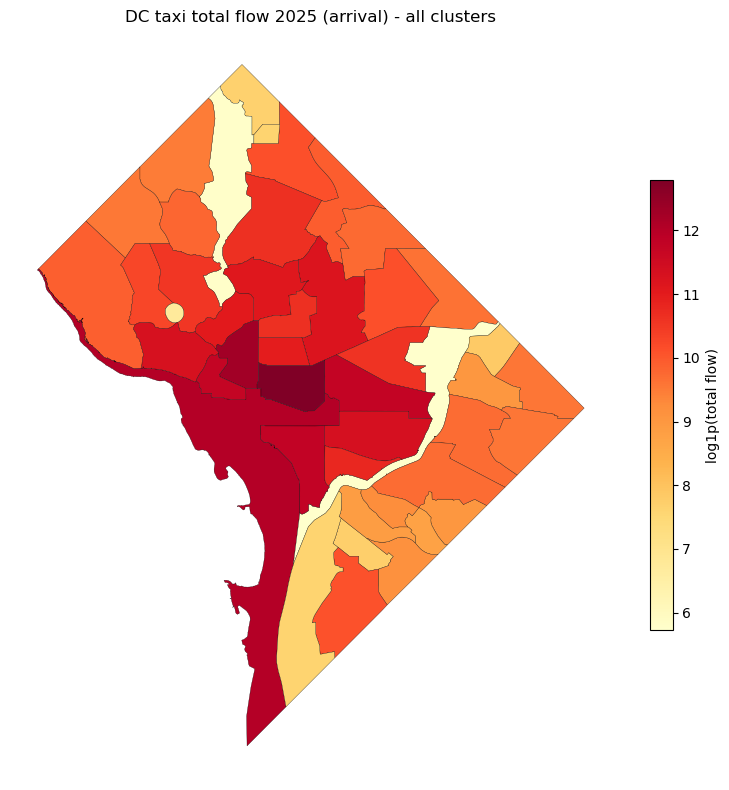

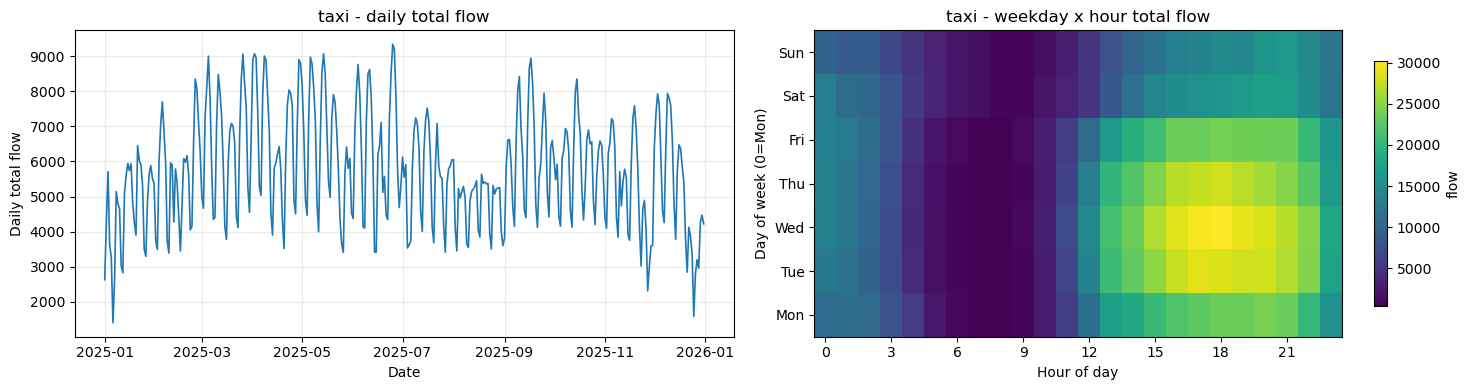

=== Sparsity report: bike ===
  shape=(46, 8760), total_flow=5,635,874
  nnz cells=267,016/402,960  zero_rate=33.736%
  dead regions=0/46  dead steps=1/8760
  region totals  min/Q1/med/Q3/max = 856 / 7,943 / 30,534 / 228,968 / 601,888
  step totals    min/Q1/med/Q3/max = 0 / 168 / 559 / 985 / 2,506
  step totals  (non-zero only) Q1/med/Q3 = 168 / 559 / 985
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:00:00


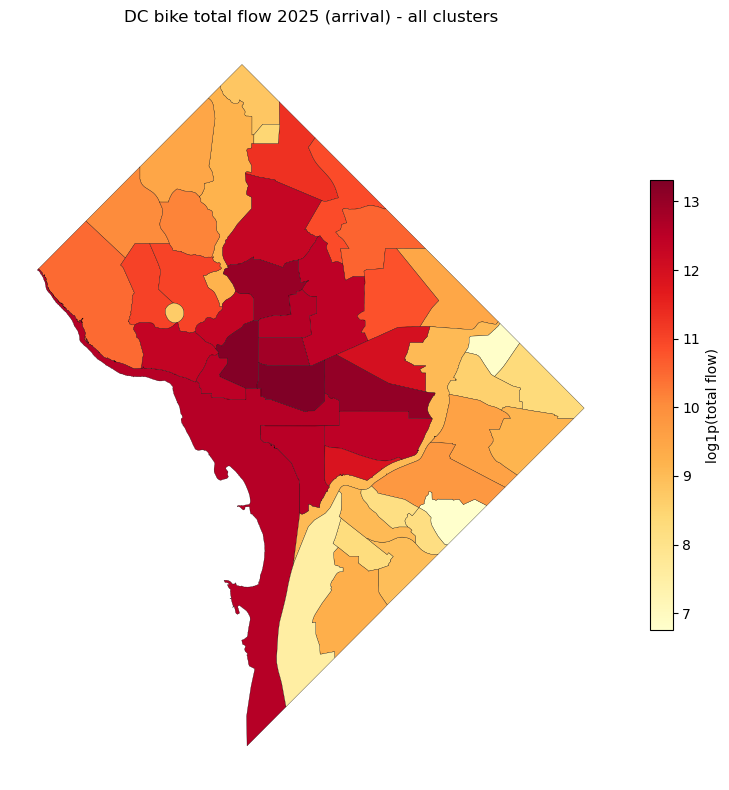

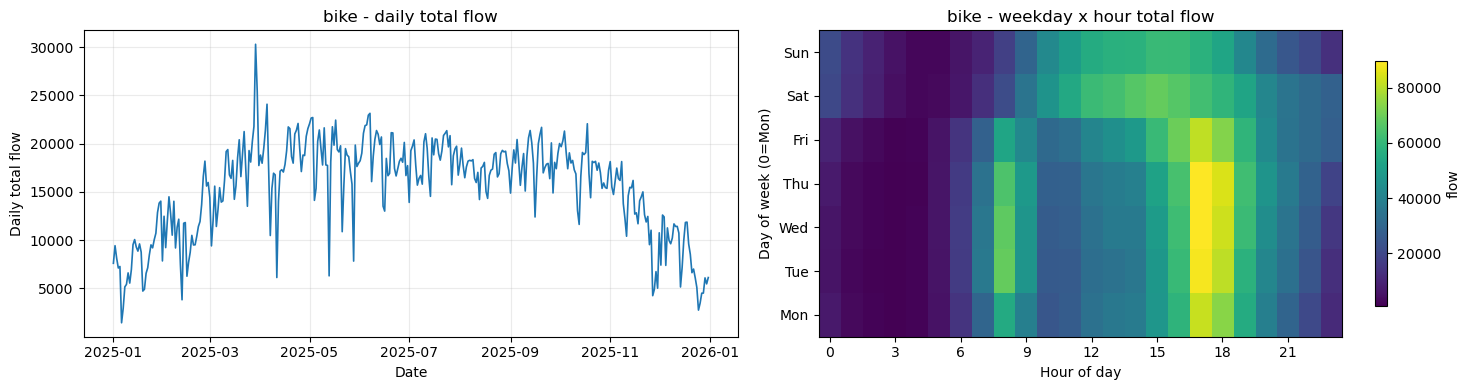

In [13]:
cluster_active = TARGET_CLUSTERS is not None and (not isinstance(TARGET_CLUSTERS, str) or TARGET_CLUSTERS.lower() != "all")
for name, arr, time_index in MOBILITY_VIZ:
    sparsity_report(name, arr, time_index)
    plot_cluster_heat(clusters, arr.sum(axis=1), f"DC {name} total flow {YEAR} ({FLOW_MODE}) - all clusters")
    if cluster_active:
        sub = arr[sel_idx]
        sparsity_report(f"{name} [{TARGET_TAG}]", sub, time_index)
        plot_cluster_heat(clusters_sel, sub.sum(axis=1), f"DC {name} total flow {YEAR} ({FLOW_MODE}) - {TARGET_TAG}")
    plot_temporal_panels(name, arr, time_index)

## Generate dataset (NDT)

Reorder the merged `(N, M, T)` tensor to `(N, D, T)` and feed it to
`utils/generate.py` with `--fmt NDT --clip_neg --per_channel --log1p`, producing
the `dc_60min` dataset across the standard horizon suite (12to1 ... 12to12).

In [14]:
if TARGET_CLUSTERS is not None and (not isinstance(TARGET_CLUSTERS, str) or TARGET_CLUSTERS.lower() != "all"):
    src_path = OUT_DIR / f"dc_{cluster_tag}_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
    DATASET = f"dc_{cluster_tag}_60min"
else:
    src_path = OUT_DIR / f"dc_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
    DATASET = "dc_60min"

merged_arr = np.load(src_path)
M = len(MERGE_MOBILITIES)
if merged_arr.shape[0] == M and merged_arr.shape[1] != M:
    ndt = merged_arr.transpose(1, 0, 2)   # (M, N, T) -> (N, D, T)
elif merged_arr.shape[1] == M:
    ndt = merged_arr                       # already (N, D, T)
else:
    raise ValueError(f"Cannot locate mobility axis (M={M}) in {merged_arr.shape}")
ndt_path = src_path.with_name(src_path.stem + "_NDT.npy")
np.save(ndt_path, ndt)
print(f"{ndt_path} shape={tuple(ndt.shape)} (N, D, T) with D={M} mobilities")

for hy in [1, 3, 6, 9, 12]:
    subprocess.run([
        "python3", "/home/dy23a.fsu/st/utils/generate.py",
        "--data_path", str(ndt_path),
        "--fmt", "NDT",
        "--clip_neg",
        "--per_channel",
        "--log1p",
        "--dataset", DATASET,
        "--years", f"{YEAR}_12to{hy}",
        "--seq_length_x", "12",
        "--seq_length_y", str(hy),
    ], check=True)

/home/dy23a.fsu/st/datasets/raw/DC/dc_taxi_bike_2025_60min_NDT.npy shape=(46, 2, 8760) (N, D, T) with D=2 mobilities
Loaded /home/dy23a.fsu/st/datasets/raw/DC/dc_taxi_bike_2025_60min_NDT.npy, raw shape: (46, 2, 8760)
Clipped negative values to 0
Reordered NDT → TND, shape: (8760, 46, 2)
Raw — max: 452, min: 0, mean: 9.5998, std: 22.0093
Index range: [11, 8759), total=8748, train=6998, val=875, test=875
MinMaxScaler(log1p=True) min: [0.0, 0.0], max: [5.393627643585205, 6.115891933441162]
Normalized — max: 1.0000, min: 0.0000, mean: 0.2230, std: 0.2257
Saved meta.json to /blue/gtyson.fsu/dy23a.fsu/datasets/dc_60min/2025_12to1/meta.json
Saved to /blue/gtyson.fsu/dy23a.fsu/datasets/dc_60min/2025_12to1
Saved info.json to /blue/gtyson.fsu/dy23a.fsu/datasets/dc_60min/2025_12to1/info.json
Loaded /home/dy23a.fsu/st/datasets/raw/DC/dc_taxi_bike_2025_60min_NDT.npy, raw shape: (46, 2, 8760)
Clipped negative values to 0
Reordered NDT → TND, shape: (8760, 46, 2)
Raw — max: 452, min: 0, mean: 9.5998,

## Adjacency

Distance-based adjacency over the selected cluster centroids, saved alongside
the dataset. Centroids are computed in a projected CRS (EPSG:26985, NAD83 /
Maryland, meters) to avoid the geographic-CRS centroid warning.

In [15]:
sys.path.insert(0, "/home/dy23a.fsu/st/utils")
from get_adj_mat import get_adjacency_matrix

ADJ_DIR = Path("/home/dy23a.fsu/st/datasets") / DATASET
ADJ_DIR.mkdir(parents=True, exist_ok=True)
ADJ_OUT = ADJ_DIR / "dc.npy"
adj_gdf = clusters_sel if cluster_active else clusters

ctr = adj_gdf.set_geometry("geometry").to_crs("EPSG:26985").centroid.reset_index(drop=True)
N_adj = len(ctr)
ids = list(range(N_adj))
distance = [[i, j, ctr[i].distance(ctr[j])] for i in ids for j in ids]
adj_mx = get_adjacency_matrix(distance_df=distance, sensor_ids=ids)
np.save(ADJ_OUT, adj_mx)
print(f"Saved {ADJ_OUT} shape={adj_mx.shape}")

Saved /home/dy23a.fsu/st/datasets/dc_60min/dc.npy shape=(46, 46)
